# Setup and clip HRSL

Load the raw HRSL population raster, clip it to the Delhi study-area bounding box, inspect the result, and save the clipped raster for downstream notebooks.

In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.mask import mask

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import (
    CITY_NAME,
    BBOX,
    CRS_WGS84,
    FILES,
    ensure_project_dirs,
    get_bbox_gdf,
    savefig,
    print_config_summary,
)

ensure_project_dirs()
print_config_summary()

ImportError: cannot import name 'hrsl_raw' from 'config' (/Users/suvo/Projects/urban-healthcare/config.py)

In [2]:
bbox_gdf = get_bbox_gdf()
bbox_gdf

,city,geometry
0,Delhi,"POLYGON ((77.4 28.4, 77.4 28.95, 76.8 28.95, 7..."


In [9]:
hrsl_path = FILES["hrsl_raw"]

with rasterio.open(hrsl_path) as src:
    print("HRSL path:", hrsl_path)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Width x Height:", src.width, "x", src.height)
    print("Count:", src.count)
    print("Dtype:", src.dtypes[0])
    print("Nodata:", src.nodata)

HRSL path: /Users/suvo/Projects/urban-healthcare/data/raw/population/population_20_lon_70_general-v1.5.tif
CRS: EPSG:4326
Bounds: BoundingBox(left=69.99569444444445, bottom=19.995694444436438, right=80.00458333334134, top=30.004583333333333)
Width x Height: 36032 x 36032
Count: 1
Dtype: float64
Nodata: nan


In [10]:
print("BBOX CRS:", bbox_gdf.crs)
print("BBOX bounds:", bbox_gdf.total_bounds)

BBOX CRS: EPSG:4326
BBOX bounds: [76.8  28.4  77.4  28.95]


In [11]:
with rasterio.open(hrsl_path) as src:
    bbox_for_mask = bbox_gdf.to_crs(src.crs)

    print("Raster CRS:", src.crs)
    print("Reprojected bbox bounds:", bbox_for_mask.total_bounds)
    print("Raster bounds:", src.bounds)

    clipped_array, clipped_transform = mask(
        src,
        bbox_for_mask.geometry,
        crop=True
    )

    clipped_meta = src.meta.copy()
    clipped_meta.update({
        "height": clipped_array.shape[1],
        "width": clipped_array.shape[2],
        "transform": clipped_transform
    })

print("Clipped shape:", clipped_array.shape)

Raster CRS: EPSG:4326
Reprojected bbox bounds: [76.8  28.4  77.4  28.95]
Raster bounds: BoundingBox(left=69.99569444444445, bottom=19.995694444436438, right=80.00458333334134, top=30.004583333333333)
Clipped shape: (1, 1981, 2161)


In [12]:
clipped_path = FILES["hrsl_clipped"]

with rasterio.open(clipped_path, "w", **clipped_meta) as dst:
    dst.write(clipped_array)

print("Saved clipped raster to:", clipped_path)

Saved clipped raster to: /Users/suvo/Projects/urban-healthcare/data/processed/hrsl_clipped_delhi.tif


Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/01_hrsl_clipped_overview.png


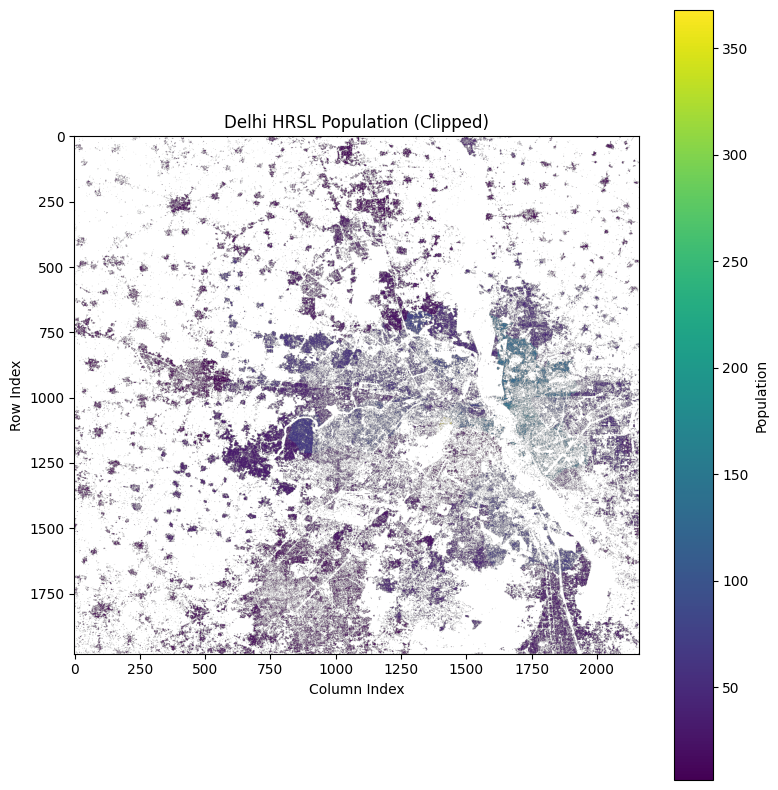

In [13]:
band1 = clipped_array[0]

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(band1, cmap="viridis")
ax.set_title(f"{CITY_NAME} HRSL Population (Clipped)")
ax.set_xlabel("Column Index")
ax.set_ylabel("Row Index")
plt.colorbar(im, ax=ax, label="Population")
plt.tight_layout()

savefig(fig, "01_hrsl_clipped_overview.png")
plt.show()

Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/01_delhi_bbox.png


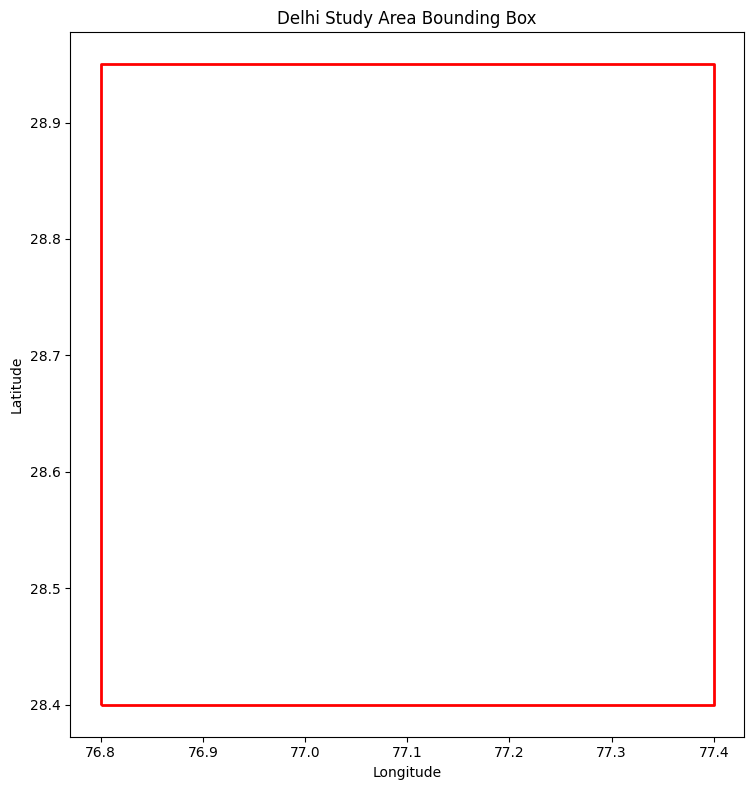

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))
bbox_gdf.boundary.plot(ax=ax, color="red", linewidth=2)
ax.set_title(f"{CITY_NAME} Study Area Bounding Box")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()

savefig(fig, "01_delhi_bbox.png")
plt.show()